<a href="https://colab.research.google.com/github/sridevipandru-projects/classicalml_decissiontree/blob/feat_decissiontree/decisiontree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Person_ID                  6000 non-null   object 
 1   Age                        6000 non-null   int64  
 2   Gender                     6000 non-null   object 
 3   Height_cm                  6000 non-null   float64
 4   Weight_kg                  6000 non-null   float64
 5   BMI                        6000 non-null   float64
 6   Activity_Level             6000 non-null   object 
 7   Daily_Calorie_Requirement  6000 non-null   int64  
 8   Daily_Calorie_Consumed     6000 non-null   int64  
 9   Protein_Intake_g           6000 non-null   float64
 10  Carbohydrate_Intake_g      6000 non-null   float64
 11  Fat_Intake_g               6000 non-null   float64
 12  Water_Intake_Liters        6000 non-null   float64
 13  Diet_Type                  6000 non-null   objec

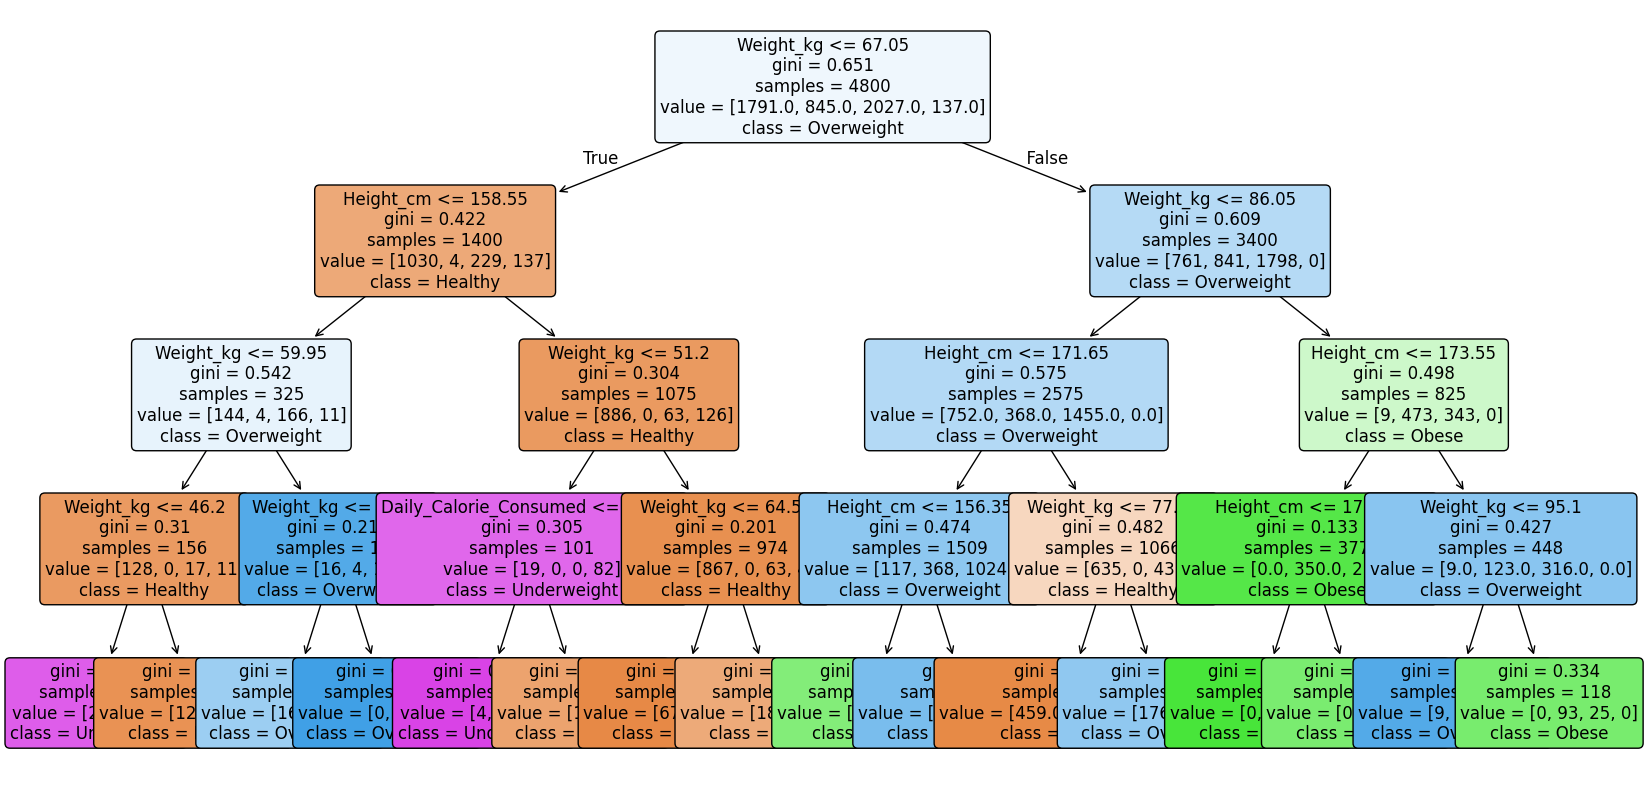

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
!pip install category-encoders # Install the missing library
import category_encoders as ce
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn import tree
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
data='/content/healthy_diet_calorie_intake.csv'
df=pd.read_csv(data)
df.head() #display top 5 rows in data set
df.shape #gives the count of rows and cols
df.info() # to check empty rows and data types of the columns
df['Health_Status'].value_counts() #to see all the categories of the variable and those categories frequency, we can see whether the data set is balanced or imbalanced
df.isnull().sum() #to check the missing values in the data set
df.head()
print(df['Health_Status'].value_counts())
# sns.boxplot(x='Health_Status', y='BMI', data=df)
# plt.show()
X=df.drop(['Health_Status','Person_ID','BMI'],axis=1)
y=df['Health_Status']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape,X_test.shape,y_train.shape,y_test.shape
X_train.head()
encoder=ce.OrdinalEncoder(cols=['Gender','Activity_Level','Diet_Type'])
X_train=encoder.fit_transform(X_train)
X_test=encoder.transform(X_test)
X_train.head()
calc_gini=DecisionTreeClassifier(criterion='gini',max_depth=4,random_state=42)#ensures same train_test split every time we run the code
calc_gini.fit(X_train,y_train)
# calc_entropy=DecisionTreeClassifier(criterion='entropy',max_depth=3,random_state=0)
# calc_entropy.fit(X_train,y_train)
y_pred=calc_gini.predict(X_test)
print("test accuracy-using criteria gini impurity",accuracy_score(y_test,y_pred))
# y_pred=calc_entropy.predict(X_test)
# print("test accuracy-using criteria entropy",accuracy_score(y_test,y_pred)
y_pred_train=calc_gini.predict(X_train)
print("train accuracy-using criteria gini impurity",accuracy_score(y_train,y_pred_train))
plt.figure(figsize=(20,10))
tree.plot_tree(calc_gini.fit(X_train,y_train),feature_names=X_train.columns,class_names=calc_gini.classes_,filled=True,rounded=True,fontsize=12)
plt.show()


